<a href="https://colab.research.google.com/github/CodeSage54/Deep-Learning/blob/main/TimeSeries_RNN_LSTM/Tesla_Stock_Prices_Prediction_using_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:** Build Stock price prediction model using RNN and LSTM to predict Tesla Stock Prices

`Disclaimer: No trading tips given`


---



## Data Cleansing and exploration

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
data = pd.read_csv("/content/drive/MyDrive/datasets/Tesla.csv.csv")

In [6]:
data.sample(5)

,Date,Open,High,Low,Close,Volume,Adj Close
434,3/19/2012,35.259998,35.320000,34.540001,34.980000,1015600,34.980000
284,8/12/2011,25.600000,27.139999,25.360001,26.309999,1009100,26.309999
262,7/13/2011,28.430000,29.030001,27.900000,28.639999,1066000,28.639999
1447,3/30/2016,235.089996,235.500000,226.500000,226.889999,4033000,226.889999
1597,10/31/2016,202.490005,202.490005,195.809998,197.729996,4692300,197.729996




1. **Open:** The opening price of the stock on a particular trading day. This is the price at which the first trade is executed when the market opens.
2.  **High:** The highest price at which the stock traded during the `trading day`. It indicates the maximum value that traders were willing to pay for the stock on that day.
3. **Low:** The lowest price at which the stock traded during the trading day. This represents the minimum value for the stock within the trading day.
4. **Close:** The closing price of the stock for the day. It is the last price at which the stock was traded before the market closed. This is one of the most commonly reported and used prices because it reflects the final consensus value of the stock for the day.
5. **Volume:** The total number of shares or contracts traded for the stock during the trading day. It reflects the level of activity or liquidity for the stock. Higher volume indicates more trading activity and, typically, higher investor interest.
6. **Adj Close (Adjusted Close):** This is the closing price adjusted for corporate actions like `stock splits`, `dividends`, and `new stock offerings`. Adjusted close provides a more accurate reflection of a stock’s value and price movements over time because it accounts for events that could affect the stock price directly.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


**Convert the column `date` into proper `date time format`**

In [8]:
data['Date'] = pd.to_datetime(data['Date']) #converts date into date time format

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1692 non-null   datetime64[ns]
 1   Open       1692 non-null   float64       
 2   High       1692 non-null   float64       
 3   Low        1692 non-null   float64       
 4   Close      1692 non-null   float64       
 5   Volume     1692 non-null   int64         
 6   Adj Close  1692 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 92.7 KB


In [10]:
data.describe()

,Date,Open,High,Low,Close,Volume,Adj Close
count,1692,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,2013-11-06 02:53:37.021276416,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,2012-03-01 18:00:00,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,2013-11-05 12:00:00,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,2015-07-14 06:00:00,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,2017-03-17 00:00:00,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009
std,NaN,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187


 Let us check if there is any `missing data`

In [11]:
data.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


Plot the `open price` distribution

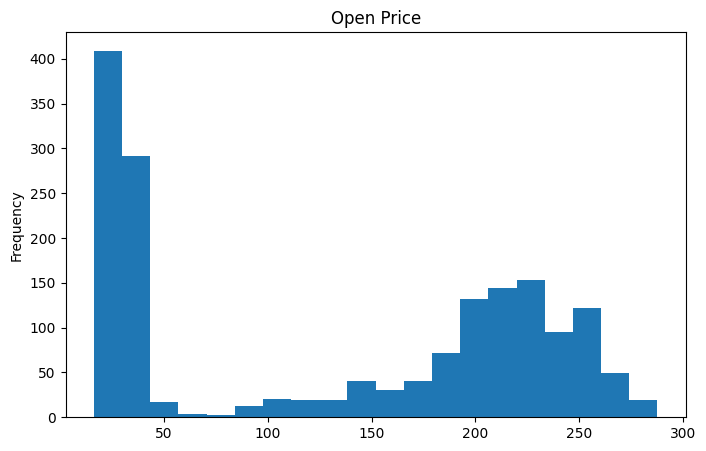

In [12]:
plt.subplots(figsize = (8,5))
data['Open'].plot(kind='hist', bins=20, title='Open Price')
plt.show()

In [13]:
print("Number of trading days in Tesla data:", data['Date'].nunique())

Number of trading days in Tesla data: 1692


**Splitting the `Tesla data` into `training` and `validation` sets**

In [14]:
length_data = len(data) # rows in the data
length_data

1692

In [15]:
split_ratio = 0.70 #70% of the data is reserved for training and rest 30% is for validation
length_train = round(length_data * split_ratio)
length_validation = length_data - length_train

In [16]:
print("Data Length:", length_data)
print("Train data length:", length_train)
print("Validation data length:", length_validation)

Data Length: 1692
Train data length: 1184
Validation data length: 508


In [17]:
508/1692

0.30023640661938533

In [18]:
train_data = data[:length_train].iloc[:,:2]
train_data.head()

,Date,Open
0,2010-06-29,19.000000
1,2010-06-30,25.790001
2,2010-07-01,25.000000
3,2010-07-02,23.000000
4,2010-07-06,20.000000


In [19]:
train_data.tail()

,Date,Open
1179,2015-03-06,199.210007
1180,2015-03-09,194.389999
1181,2015-03-10,188.460007
1182,2015-03-11,191.149994
1183,2015-03-12,193.750000


In [20]:
type(train_data)

pandas.core.frame.DataFrame

In [21]:
validation_data = data[length_train:].iloc[:,:2]
validation_data.head()

,Date,Open
1184,2015-03-13,188.949997
1185,2015-03-16,192.000000
1186,2015-03-17,195.429993
1187,2015-03-18,194.960007
1188,2015-03-19,202.000000


In [22]:
validation_data.tail()

,Date,Open
1687,2017-03-13,244.820007
1688,2017-03-14,246.110001
1689,2017-03-15,257.000000
1690,2017-03-16,262.399994
1691,2017-03-17,264.000000


**Creating `ready to use training data set`**
- Convert `1D` array to `2D` array

In [23]:
dataset_train = train_data.Open.values
# Extract the Open Price in a 2-D array suitable for Models
dataset_train = np.reshape(dataset_train, (-1,1))

In [31]:
dataset_train.shape

(1184, 1)

In [32]:
dataset_train

array([[ 19.      ],
       [ 25.790001],
       [ 25.      ],
       ...,
       [188.460007],
       [191.149994],
       [193.75    ]])

**Normalization/Feature Scaling**

- dataset values will be in between `0` and `1` after scaling

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [34]:
##### Scaling the train dataset
dataset_train_scaled = scaler.fit_transform(dataset_train)

**----------Before Scaling----------**

In [35]:
dataset_train.min(), dataset_train.max()

(np.float64(16.139999), np.float64(287.670013))

***----------After Scaling----------***

In [91]:
dataset_train_scaled.min(), dataset_train_scaled.max()

(np.float64(0.0), np.float64(1.0))

### Let us visualize the `line chart` for `Tesla` Stock Open Price

**----------Before Scaling----------**

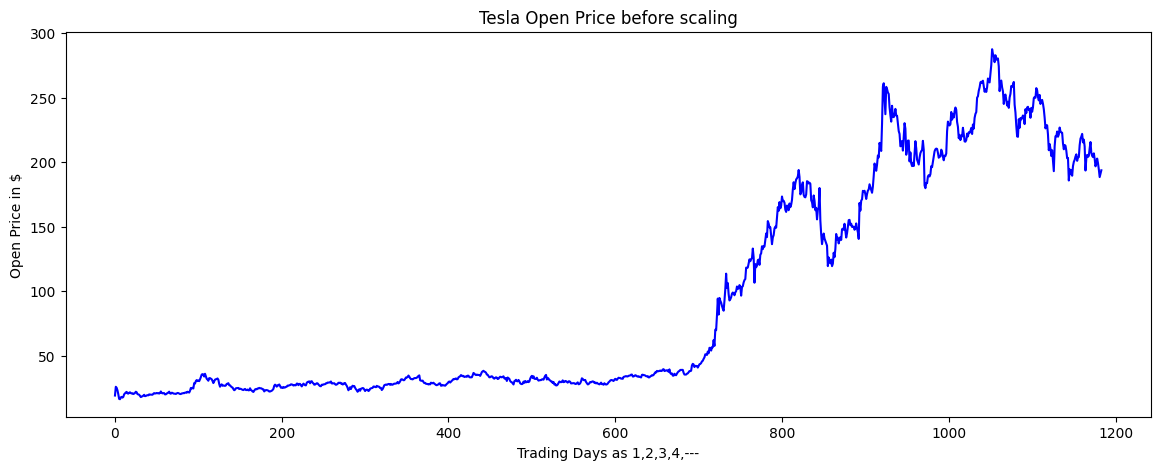

In [37]:
plt.subplots(figsize=(14,5))
plt.plot(dataset_train, color='blue', label='Tesla Stock Open Price')
plt.title("Tesla Open Price before scaling")
plt.xlabel("Trading Days as 1,2,3,4,---")
plt.ylabel("Open Price in $")
plt.show()


**----------After Scaling----------**

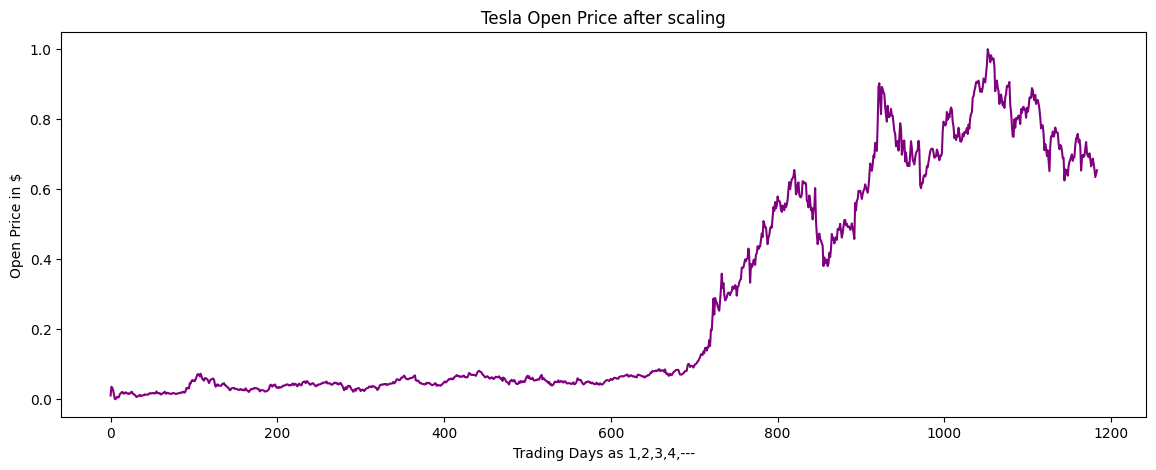

In [38]:
plt.subplots(figsize=(14,5))
plt.plot(dataset_train_scaled, color='purple', label='Tesla Stock Open Price')
plt.title("Tesla Open Price after scaling")
plt.xlabel("Trading Days as 1,2,3,4,---")
plt.ylabel("Open Price in $")
plt.show()


- **Why scaling ?** Wide range of `Open` prices lead to `unstable learning` and can go in the direction of `vanishing gradients` problem

# RNN Model

In [40]:
# Recurrent Neural Networks (RNNs) and LSTMs cannot "see" the whole chart at once like a human. They need to be fed "sequences."
# We are going to create sliding windows of 50 days each for traiining model.
# Basically feed the price of first 50 days from Day 1, predict the price for 51st day. X_train will be Day1-Day 50 price. y_train will be Day 51 price.
# Then slide the window by 1 day from Day 2 - Day 52 and  predict the price for 52nd day.

X_train = []
y_train = []

time_step =50 #currently time step is at 50

for i in range(time_step, length_train):
    X_train.append(dataset_train_scaled[i - time_step: i , 0])
    y_train.append(dataset_train_scaled[i,0])

In [44]:
print(type(X_train))

<class 'list'>


In [45]:
### convert list into np arrays
X_train, y_train = np.array(X_train), np.array(y_train)

In [46]:
print("Shape of X_train before reshape:", X_train.shape)
print("Shape of y_train before reshape:", y_train.shape)

Shape of X_train before reshape: (1134, 50)
Shape of y_train before reshape: (1134,)


In [47]:
# Time series forecasting is often referred as Univariate forecasting
# Means in the sliding  window, the same price variable is acting as a feature for 50days and target variable for 51 day.
# Keras model needs training data as a 3 D input where the last parameter is the number of features ywe are showing it.
# Since we are only having Open Price as the feature here, we will set the last diomension as 1 when reshaping X_Train.
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0],1))

print("Shape of X_train after reshape :",X_train.shape)
print("Shape of y_train after reshape :",y_train.shape)

Shape of X_train after reshape : (1134, 50, 1)
Shape of y_train after reshape : (1134, 1)


**Build the RNN model**

In [48]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

Keras RNN documentation: https://keras.io/api/layers/recurrent_layers/simple_rnn/

In [49]:
### Initialize the RNN Object
regressor = Sequential() #initializing the regressor object - sequential object

### Adding the first RNN layer and also the drop regularization
regressor.add(
    SimpleRNN(units = 50, activation='tanh', return_sequences=True, input_shape = (X_train.shape[1], 1)))

# Adding second RNN layer and dropout regulatization
regressor.add(SimpleRNN(units = 50,activation = "tanh",return_sequences = True))
regressor.add(Dropout(0.2)) # dropping out 20%

# Adding third RNN layer and dropout regulatization
regressor.add(SimpleRNN(units = 50,activation = "tanh",return_sequences = True))
regressor.add(Dropout(0.2))

# Adding fourth RNN layer and dropout regulatization
regressor.add(SimpleRNN(units = 50)) #default is tanh
regressor.add( Dropout(0.2))


### Adding the output layer
regressor.add(Dense(units=1)) # a fully connected layer with one neuron is added as the output layer

#### Compiling the RNN model
regressor.compile(optimizer = 'adam', loss="mean_squared_error", metrics=['accuracy'])

### Training the RNN
history = regressor.fit(X_train, y_train, epochs=50, batch_size=32)


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.0000e+00 - loss: 0.6832
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0027 - loss: 0.3224
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.0036 - loss: 0.1862
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.0000e+00 - loss: 0.0994
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 9.6639e-05 - loss: 0.0597
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 8.6409e-04 - loss: 0.0557
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0000e+00 - loss: 0.0353
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 5.9807e-04 - loss: 0.0266
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 6.9467e-04 - loss: 0.0270
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 9.6639e-05 - loss: 0.0225
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 3.6086e-04 - loss: 0.0181
Epoch 12/50
36/36 ━━━━━━━━━

**Evaluating the RNN model**

In [50]:
y_pred = regressor.predict(X_train) #predictions

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [51]:
y_train = scaler.inverse_transform(y_train) # scaling back from 0-1 to original values
y_pred = scaler.inverse_transform(y_pred) # scaling back from 0-1 to original values

**Let us visualize the actual vs predicted for training**

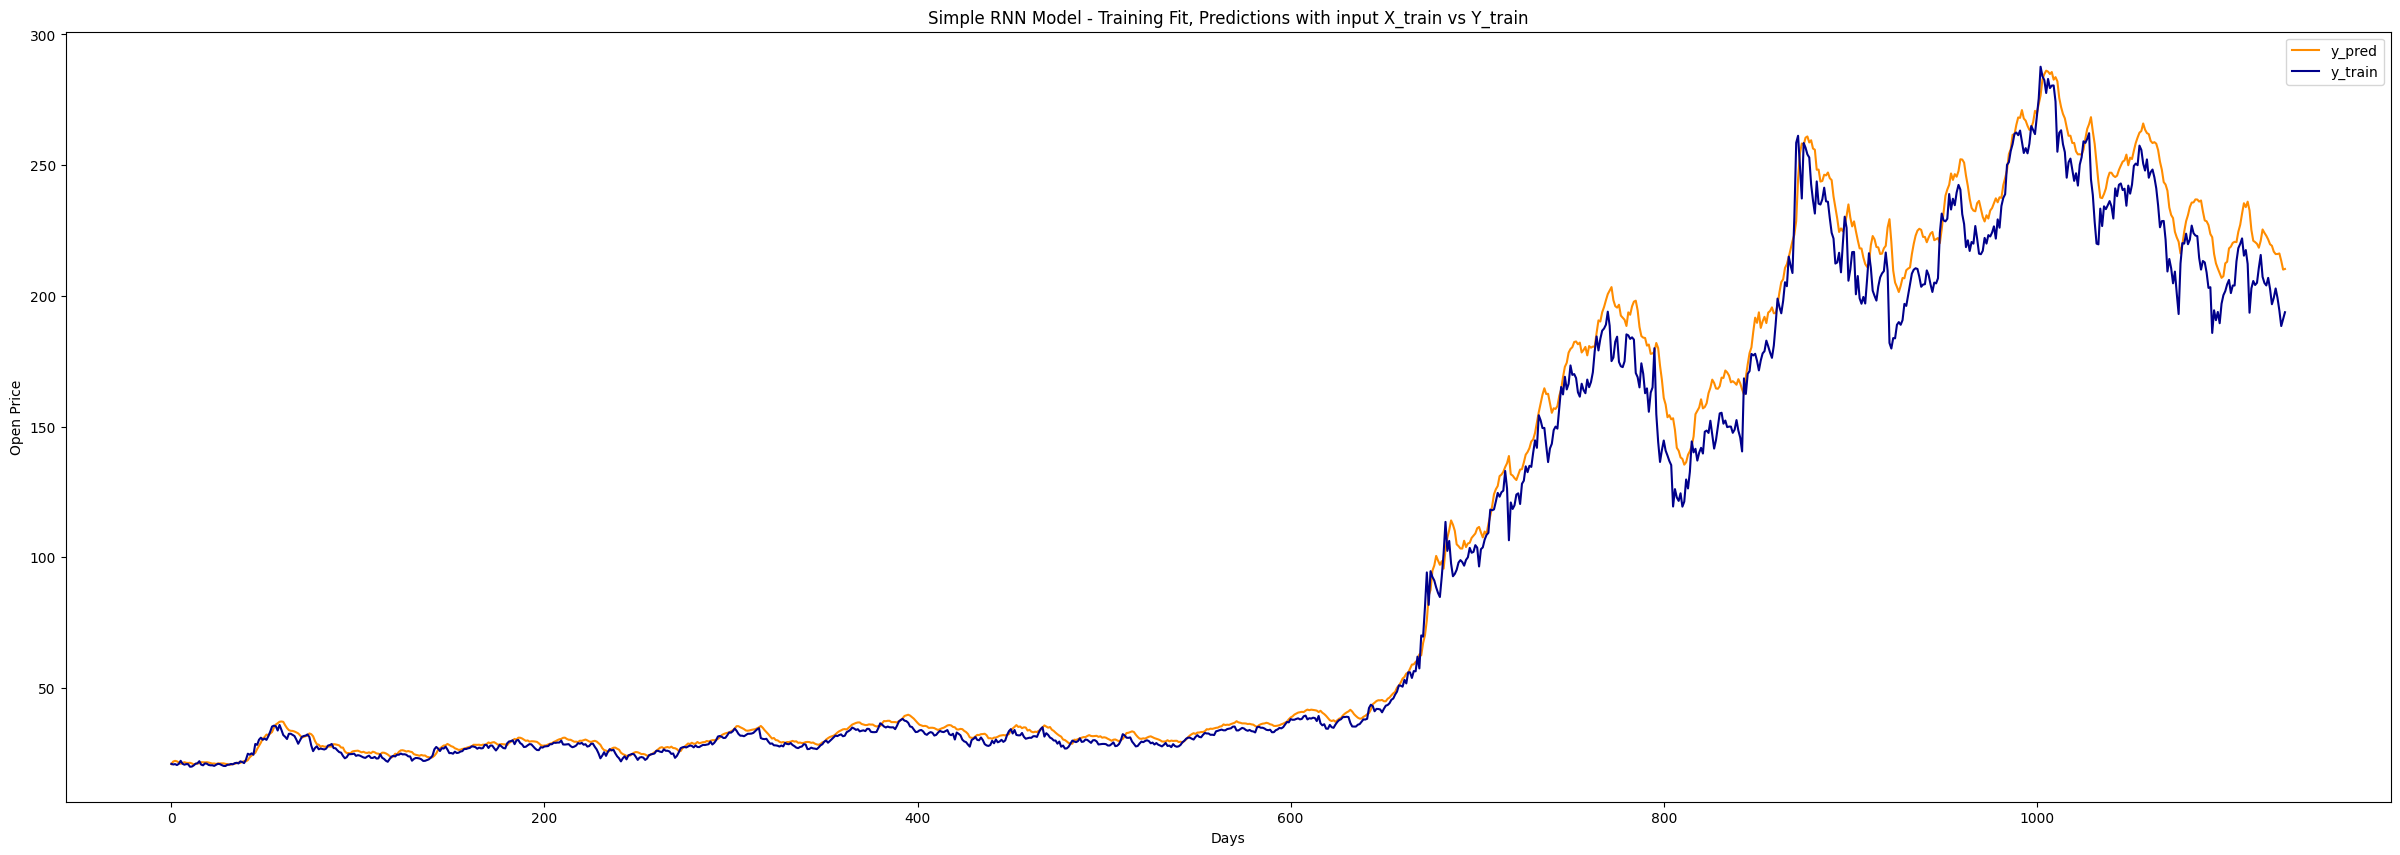

In [52]:
#### visualization
plt.figure(figsize = (30,10))
plt.plot(y_pred, color='darkorange', label="y_pred")
plt.plot(y_train, color="darkblue", label="y_train")
plt.xlabel("Days")
plt.ylabel("Open Price")
plt.title("Simple RNN Model - Training Fit, Predictions with input X_train vs Y_train")
plt.legend()
plt.show()

**Let us create the validation dataset**

In [53]:
dataset_validation = validation_data.Open.values #getting open price for validation data and getting it into array
dataset_validation = np.reshape(dataset_validation, (-1,1)) # converting 1D array to 2D array
scaled_dataset_validation =  scaler.fit_transform(dataset_validation)  # scaling open values to between 0 and 1
print("Shape of scaled validation dataset :",scaled_dataset_validation.shape)

Shape of scaled validation dataset : (508, 1)


**Creating test/validation dataset from validation data**

In [54]:
# Creating X_test and y_test
X_test = []
y_test = []

for i in range(time_step, length_validation):
    X_test.append(scaled_dataset_validation[i-time_step:i,0])
    y_test.append(scaled_dataset_validation[i,0])

# Converting to array
X_test, y_test = np.array(X_test), np.array(y_test)

In [55]:
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",y_test.shape)

Shape of X_test before reshape : (458, 50)
Shape of y_test before reshape : (458,)


In [56]:
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))  # reshape to 3D array
y_test = np.reshape(y_test, (-1,1))  # reshape to 2D array

In [57]:
print("Shape of X_test after reshape :",X_test.shape)
print("Shape of y_test after reshape :",y_test.shape)

Shape of X_test after reshape : (458, 50, 1)
Shape of y_test after reshape : (458, 1)


**Evaluating the trained model on the validation dataset**

In [58]:
y_pred_of_test = regressor.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [59]:
### Scaling back to original values
y_pred_of_test = scaler.inverse_transform(y_pred_of_test)

In [60]:
y_pred_of_test.min(), y_pred_of_test.max()

(np.float32(156.83006), np.float32(277.05975))

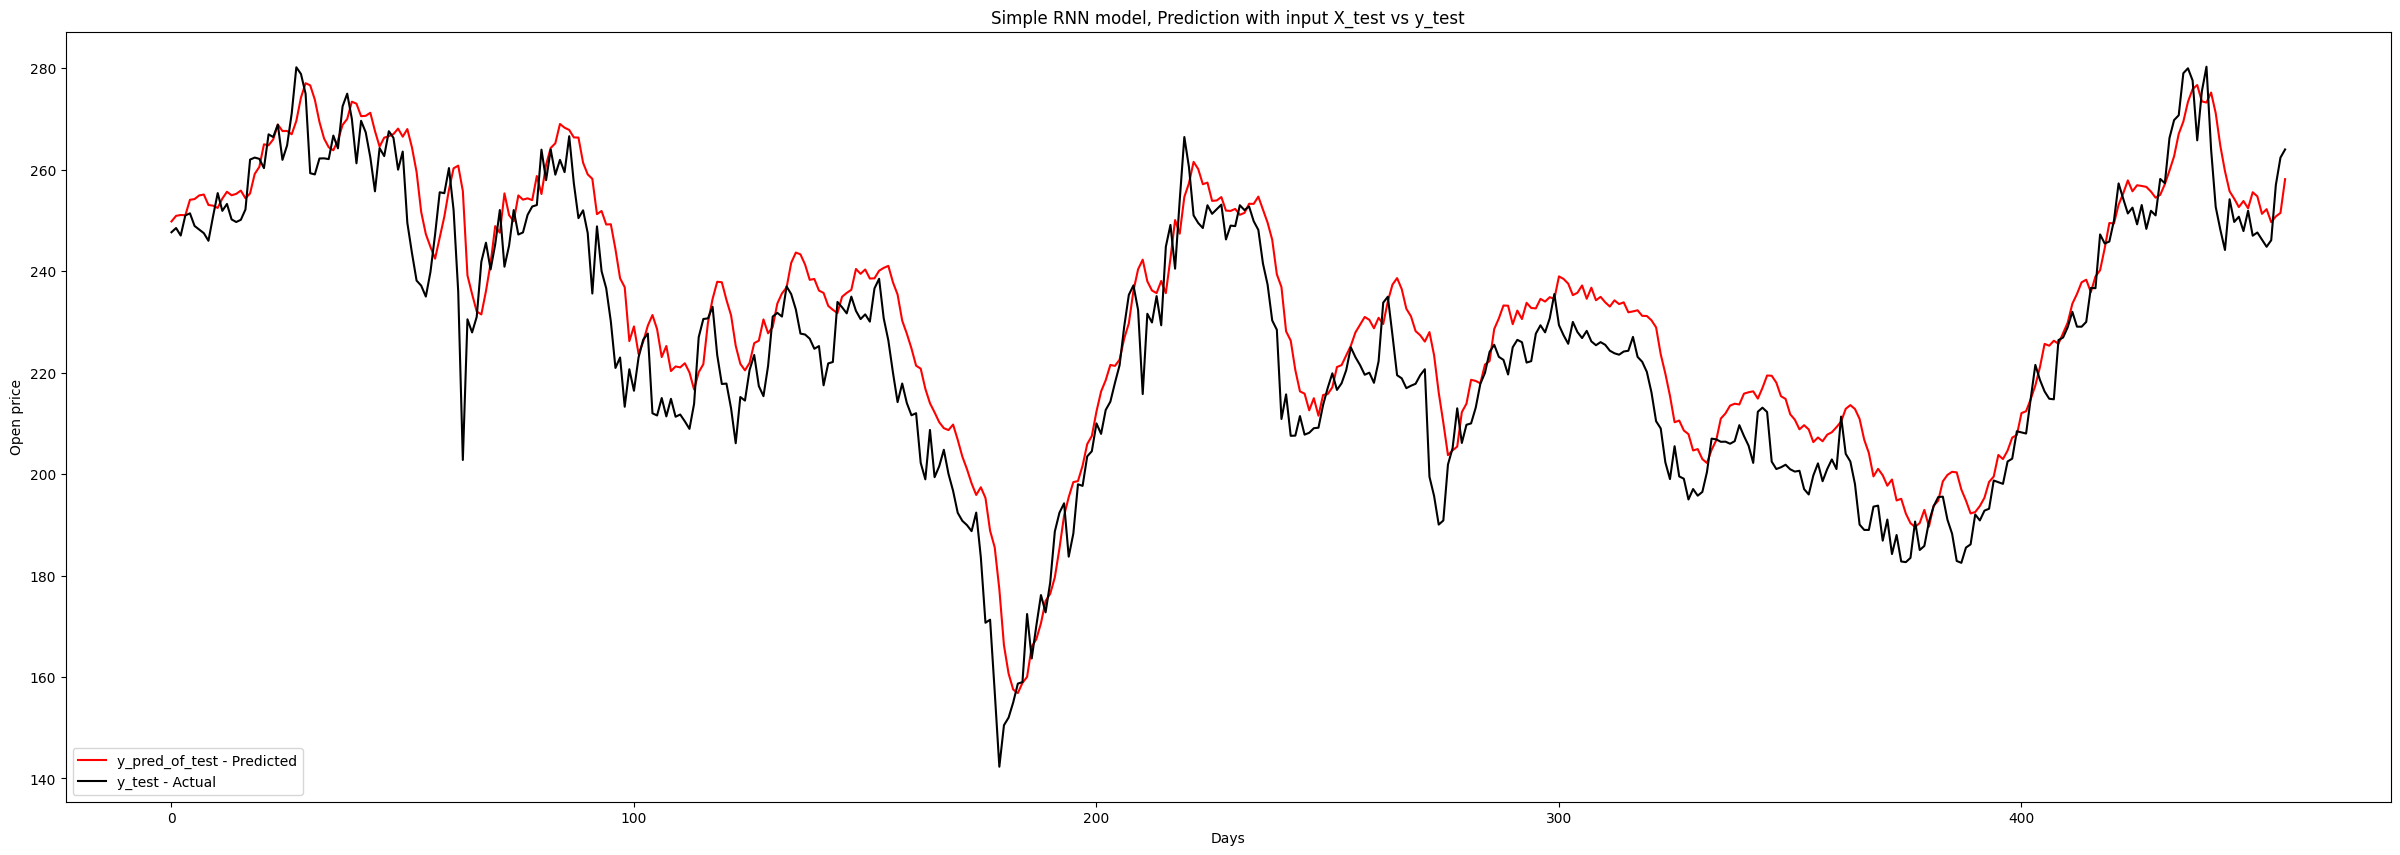

In [61]:
# visualisation
plt.figure(figsize = (30,10))
plt.plot(y_pred_of_test, label = "y_pred_of_test - Predicted", c = "red")
plt.plot(scaler.inverse_transform(y_test), label = "y_test - Actual", c = "black")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Prediction with input X_test vs y_test")
plt.legend()
plt.show()

**SIMPLE RNN MODEL - TRAIN VALIDATION - PREDICTION**

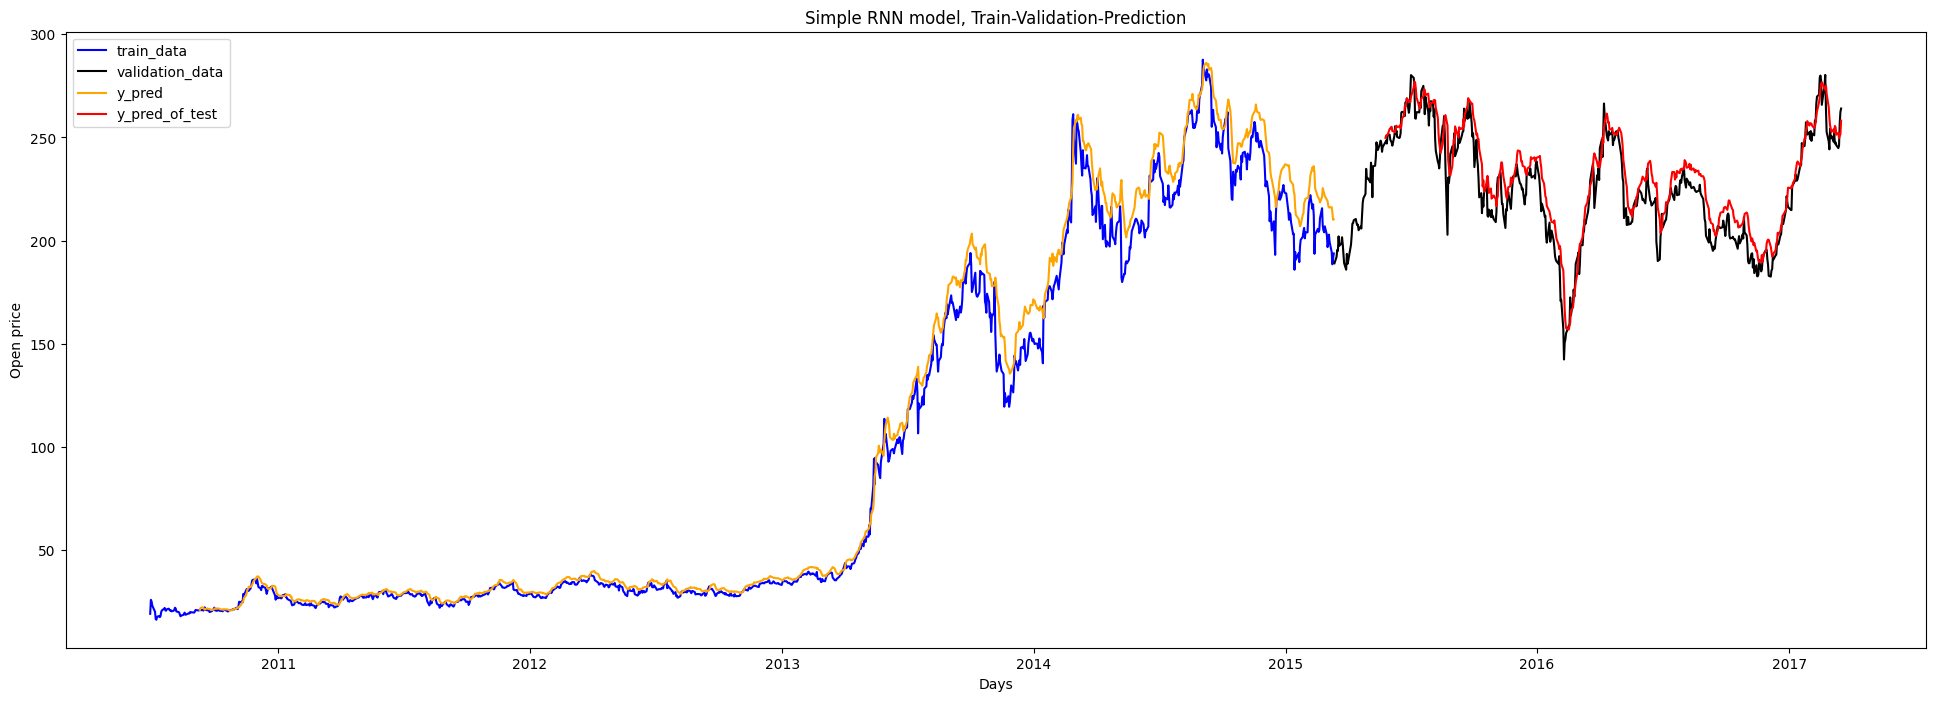

In [62]:
# Visualisation
plt.subplots(figsize =(24,8))
plt.plot(train_data.Date, train_data.Open, label = "train_data", color = "blue")
plt.plot(validation_data.Date, validation_data.Open, label = "validation_data", color = "black")
plt.plot(train_data.Date.iloc[time_step:], y_pred, label = "y_pred", color = "orange")
plt.plot(validation_data.Date.iloc[time_step:], y_pred_of_test, label = "y_pred_of_test", color = "red")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Train-Validation-Prediction")
plt.legend()
plt.show()

# `LSTM` model

In [65]:
from keras.layers import LSTM

In [77]:
# del model_lstm

In [102]:
# Some issue caused by scaling multiple times, hence reloading and repeating the steps for LSTM.
data = pd.read_csv("/content/drive/MyDrive/datasets/Tesla.csv.csv")
train_data = data[:length_train].iloc[:,:2]
train_data.head()
validation_data = data[length_train:].iloc[:,:2]
validation_data.head()

dataset_train = train_data.Open.values
# Extract the Open Price in a 2-D array suitable for Models
dataset_train = np.reshape(dataset_train, (-1,1))


##### Scaling the train dataset
dataset_train_scaled = scaler.fit_transform(dataset_train)

In [103]:
dataset_train_scaled

array([[0.01053291],
       [0.03553936],
       [0.03262991],
       ...,
       [0.634626  ],
       [0.64453278],
       [0.65410817]])

In [104]:
# Recurrent Neural Networks (RNNs) and LSTMs cannot "see" the whole chart at once like a human. They need to be fed "sequences."
# We are going to create sliding windows of 50 days each for traiining model.
# Basically feed the price of first 50 days from Day 1, predict the price for 51st day. X_train will be Day1-Day 50 price. y_train will be Day 51 price.
# Then slide the window by 1 day from Day 2 - Day 52 and  predict the price for 52nd day.

X_train = []
y_train = []

time_step =50 #currently time step is at 50

for i in range(time_step, length_train):
    X_train.append(dataset_train_scaled[i - time_step: i , 0])
    y_train.append(dataset_train_scaled[i,0])

# convert list into np arrays
X_train, y_train = np.array(X_train), np.array(y_train)

print("Shape of X_train before reshape:", X_train.shape)
print("Shape of y_train before reshape:", y_train.shape)



# Time series forecasting is often referred as Univariate forecasting
# Means in the sliding  window, the same price variable is acting as a feature for 50days and target variable for 51st day.
# Keras model needs training data as a 3 D input where the last parameter is the number of features ywe are showing it.
# Since we are only having Open Price as the feature here, we will set the last diomension as 1 when reshaping X_Train.
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0],1))

print("Shape of X_train after reshape :",X_train.shape)
print("Shape of y_train after reshape :",y_train.shape)

Shape of X_train before reshape: (1134, 50)
Shape of y_train before reshape: (1134,)
Shape of X_train after reshape : (1134, 50, 1)
Shape of y_train after reshape : (1134, 1)


**Creating the LSTM Model**

In [105]:
model_lstm = Sequential()

### First LSTM Layer
model_lstm.add(
    LSTM(64,return_sequences=True,input_shape = (X_train.shape[1],1))) #64 LSTM Units

### Second LSTM Layer
model_lstm.add(
    LSTM(64, return_sequences= False))

### Adding Dense Layers
model_lstm.add(Dense(32)) # A fully connected layer 32 neurons # ANN hidden layer

### Output Layer with single neuron
model_lstm.add(Dense(1))

### Compiling the model
model_lstm.compile(loss="mean_squared_error", optimizer ="adam", metrics = ["accuracy"])


In [106]:
X_train.min(), X_train.max()

(np.float64(0.0), np.float64(1.0))

In [107]:
### Training the model
history2 = model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 7.4746e-04 - loss: 0.0346
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.0012 - loss: 0.0014
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 9.2906e-04 - loss: 0.0011
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0016 - loss: 0.0011
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0014 - loss: 0.0011
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 5.1138e-04 - loss: 0.0011
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 2.0402e-04 - loss: 8.9238e-04
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 8.6409e-04 - loss: 0.0011
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 9.2906e-04 - loss: 9.3294e-04
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.0018 - loss: 9.1797e-04
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 2.0402e-04 - loss: 9.5407e-04
Epoch 12/50
36/36 ━

In [109]:
X_test.min(), X_test.max()

(np.float64(0.0), np.float64(0.9999999999999998))

In [110]:
X_test = []
y_test = []

for i in range(time_step, length_validation):
    X_test.append(scaled_dataset_validation[i-time_step:i,0])
    y_test.append(scaled_dataset_validation[i,0])

# Converting to array
X_test, y_test = np.array(X_test), np.array(y_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))  # reshape to 3D array
y_test = np.reshape(y_test, (-1,1))  # reshape to 2D array


In [111]:
### 10. Evaluating the LSTM model
y_pred_of_test_lstm = model_lstm.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [112]:
y_pred_of_test_lstm = scaler.inverse_transform(y_pred_of_test_lstm)

In [113]:
y_pred_of_test_lstm.min(), y_pred_of_test_lstm.max()

(np.float32(34.66168), np.float32(287.7975))

In [114]:
y_test_for_lstm = scaler.inverse_transform(y_test)
y_test_for_lstm

array([[223.46227119],
       [225.09550888],
       [222.18324451],
       [229.99522   ],
       [230.80200599],
       [225.90229291],
       [224.48550985],
       [223.10808969],
       [220.15646242],
       [229.70006908],
       [238.65331486],
       [231.76618456],
       [234.44232859],
       [228.44071007],
       [227.43713712],
       [228.28328602],
       [232.29748534],
       [251.64048668],
       [252.42757548],
       [251.9356376 ],
       [248.3346779 ],
       [261.43991087],
       [260.39700454],
       [265.19832414],
       [251.54212271],
       [257.15016731],
       [269.56667347],
       [287.45358788],
       [284.85614211],
       [277.22125638],
       [246.36692639],
       [245.89462667],
       [252.07339398],
       [252.13242455],
       [251.83727363],
       [260.96760918],
       [256.00889701],
       [272.30187759],
       [277.22125638],
       [267.48086277],
       [250.20400642],
       [266.69377397],
       [262.22699967],
       [252

In [97]:
y_test.shape

(458, 1)

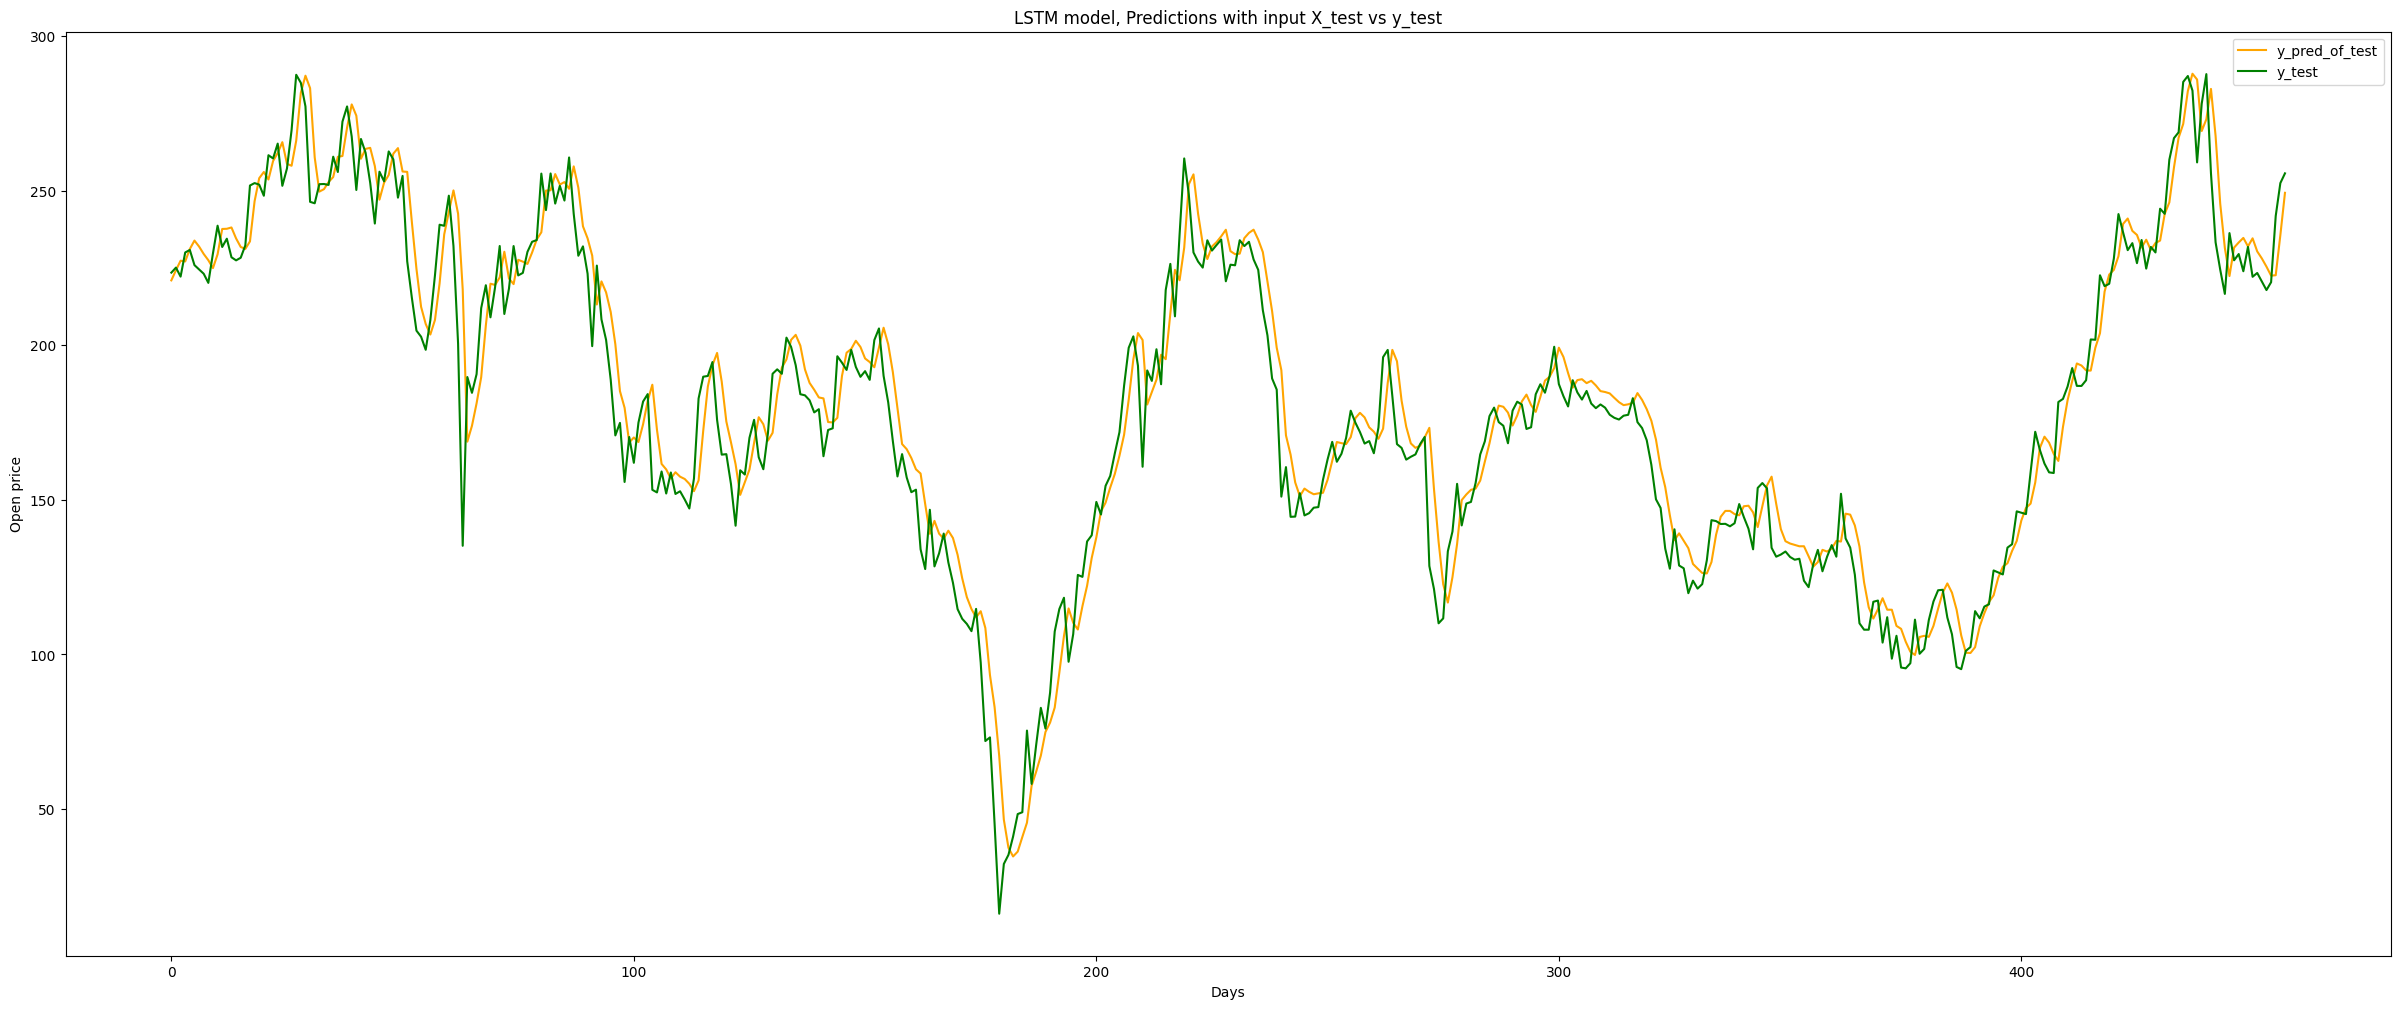

In [115]:
plt.subplots(figsize =(30,12))
plt.plot(y_pred_of_test_lstm, label = "y_pred_of_test", c = "orange" )
plt.plot(y_test_for_lstm, label = "y_test", color = "g")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("LSTM model, Predictions with input X_test vs y_test")
plt.legend()
plt.show()

# Conclusion

LSTM Fares better than RNN for this time series forecasting problem to predict the stock price of tesla. The predictions are more accurate than RNN at places where the RNN's were out by a fair margin.